In [1]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
import datetime
import sys

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader


from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import subprocess

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import scipy.stats as stats

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map,
    fix_ticks,
    get_labels,
    num_muts_column_name,
    DATASET_PATHS
)

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'code')))
from example_run_jobs import *

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
run_jobs = False

In [3]:

if run_jobs:
    for mdn in ["esm_3b", "progen2-medium", "prot_bert", "esm_150m", "progen2-small", "esm_8m", "esm_35m", "esm_650m"]:

        cmd = f"python train_classifiers_over_embeddings.py --model_name {mdn}"
        print(cmd)

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        tmp_dir_name = f"collect_all_job_results_{timestamp}"
        tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

        os.makedirs(tmp_dir_path, exist_ok=True)

        run_lsf_job(cmd, 
                    local_script_dir=tmp_dir_path,
                    code_execution_dir=os.getcwd(),
                    conda_env_name="esm_env",
                    worker_idx=None,
                    gpu=True,
                    N_cores=6,
                    rusage="64GB")

    cmd = f"python train_classifiers_over_ohe.py"

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    tmp_dir_name = f"collect_all_job_results_{timestamp}"
    tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

    os.makedirs(tmp_dir_path, exist_ok=True)

    run_lsf_job(cmd, 
                local_script_dir=tmp_dir_path,
                code_execution_dir=os.getcwd(),
                conda_env_name="esm_env",
                worker_idx=None,
                gpu=False,
                N_cores=6,
                rusage="64GB")


    for mdn in ["esm_3b", "esm_150m", "progen2-small", "esm_8m", "esm_35m", "esm_650m"]:

        cmd = f"python train_classifiers_over_embeddings.py --model_name {mdn} --dataset_name lov --regression --external_labels_column activity --mean_embeddings"
        print(cmd)

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        tmp_dir_name = f"collect_all_job_results_{timestamp}"
        tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

        os.makedirs(tmp_dir_path, exist_ok=True)

        run_lsf_job(cmd, 
                    local_script_dir=tmp_dir_path,
                    code_execution_dir=os.getcwd(),
                    conda_env_name="esm_env",
                    worker_idx=None,
                    gpu=True,
                    N_cores=6,
                    rusage="64GB")


    cmd = f"python train_classifiers_over_ohe.py --dataset_name lov --regression --external_labels_column activity"

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    tmp_dir_name = f"collect_all_job_results_{timestamp}"
    tmp_dir_path = os.path.join(os.getcwd(),  "tmp_files", tmp_dir_name)

    os.makedirs(tmp_dir_path, exist_ok=True)

    run_lsf_job(cmd, 
                local_script_dir=tmp_dir_path,
                code_execution_dir=os.getcwd(),
                conda_env_name="esm_env",
                worker_idx=None,
                gpu=False,
                N_cores=6,
                rusage="64GB")



In [4]:
df = pd.read_csv(DATASET_PATHS["gfp"])
discrete_labels = get_labels("gfp", discrete=True)
continuous_labels = get_labels("gfp", discrete=True)


probabilities_by_mutations = []
numt_muts_column = num_muts_column_name["gfp"]

n_muts = np.unique(df[numt_muts_column].to_numpy())
n_muts = n_muts[n_muts > 0]
for i in n_muts:
    counts = np.unique(discrete_labels[df[numt_muts_column] == i], return_counts=True)
    row = np.array([
        np.array([i]).astype(float)[0].item(),
        counts[1][0] / sum(counts[1]), 
        1 - counts[1][0] / sum(counts[1])
    ])
    probabilities_by_mutations.append(row)

gfp_muts = np.stack(probabilities_by_mutations)[:,1:]

In [7]:
def plot_mutation_model_performance(
    color_map, 
    df_all, 
    pred_begin, 
    min_muts, 
    n_muts_to_check, 
    feature_to_plot, 
    probabilities_by_mutations=None,
    output_dir=None,
    min_max_y=False
):
    filtered_df_all = df_all[df_all["model_name"].isin(color_map.keys())]
    col_size = 1.35
    row_size = col_size * n_muts_to_check
    title_fontsize = 8
    label_fontsize = 9
    tick_fontsize = 9
    legend_fontsize = 7

    plot_boxplots = False
    fig, axs = plt.subplots(2, n_muts_to_check, figsize=(row_size, 0.3 + col_size*2), constrained_layout=True)

    if min_max_y:
        # calculate global y min/max for line plots if needed
        all_measurements = []
        for i in range(min_muts, min_muts+n_muts_to_check):
            sub_df = filtered_df_all[filtered_df_all["test_mutations"] == i]
            train_sub_df = sub_df[(sub_df["train_mutations"] < i) & (sub_df["train_mutations"] >= pred_begin)]
            for model in color_map.keys():
                vals = train_sub_df[(train_sub_df["model_name"] == model)][feature_to_plot].values
                vals = vals[~np.isnan(vals)]
                if len(vals) > 0:
                    all_measurements.extend(vals)
        if len(all_measurements) > 0:
            global_ymin = np.nanmin(all_measurements)
            global_ymax = np.nanmax(all_measurements)
        else:
            global_ymin = 0
            global_ymax = 1

    for i in range(min_muts, min_muts+n_muts_to_check):
        col = i - min_muts
        axs[0, col].grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        axs[1, col].grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.7)
        axs[0, col].spines['right'].set_visible(False)
        axs[1, col].spines['right'].set_visible(False)
        axs[0, col].spines['top'].set_visible(False)
        axs[1, col].spines['top'].set_visible(False)

        sub_df = filtered_df_all[filtered_df_all["test_mutations"] == i]
        train_sub_df = sub_df[(sub_df["train_mutations"] < i) & (sub_df["train_mutations"] >= pred_begin)]
        n_train_muts = len(np.unique(train_sub_df["train_mutations"]))
        x = np.arange(n_train_muts)
        width = 1/n_muts_to_check
        multiplier = 0

        # --- SWAP BEGINS: original axs[0] code moved to axs[1], and boxplot code to axs[0] ---

        # First plot what *was* on row 1 (boxplot) on axs[0]
        boxplot_data = []
        model_names = []
        
        for model in color_map.keys():
            box_vals = filtered_df_all[(filtered_df_all["test_mutations"] == i) & (filtered_df_all["model_name"] == model)][feature_to_plot].dropna().values
            if len(box_vals) > 0:
                if box_vals.ndim == 2:
                    box_vals = box_vals.squeeze()
                boxplot_data.append(box_vals)
                model_names.append(model)
                
        bp = axs[0, col].boxplot(
            boxplot_data,
            patch_artist=True,
            boxprops=dict(linewidth=1, color='black'),
            medianprops=dict(color='black', linewidth=1),
            whiskerprops=dict(linewidth=1, color='black'),
            capprops=dict(linewidth=1, color='black'),
            flierprops=dict(markerfacecolor='black', marker='o', markersize=3.5, markeredgecolor='black', linestyle='none')
        )        

        for patch, model in zip(bp['boxes'], model_names):
            patch.set_facecolor(color_map[model])
        axs[0, col].set_xlabel('Model', fontsize=label_fontsize, labelpad=3)
        axs[0, col].set_xticklabels([])
        axs[0, col].tick_params(axis='y', labelsize=tick_fontsize)

        if feature_to_plot == "top_100_pct":
            all_box_vals = np.concatenate([np.array(vals).flatten() for vals in boxplot_data if np.all(~np.isnan(vals))])
            y_min = np.nanmin(all_box_vals)
            y_max = np.nanmax(all_box_vals)
            y_pad = (y_max - y_min) * 0.1 if y_max > y_min else 0.05
            y_lower = max(0, y_min - y_pad)
            y_upper = min(1, y_max + y_pad)
            for s in [0.5, 0.2, 0.1]:
                dec_y_lower = np.ceil(y_lower / s) * s
                dec_y_upper = np.floor(y_upper / s) * s
                n_ticks = int((dec_y_upper - dec_y_lower) / s) + 1
                if n_ticks >= 3 and n_ticks <= 10:
                    tick_step = s
                    break
            else:
                tick_step = 0.1
                dec_y_lower = np.ceil(y_lower / tick_step) * tick_step
                dec_y_upper = np.floor(y_upper / tick_step) * tick_step

            y_ticks = np.arange(dec_y_lower, dec_y_upper + tick_step / 2, tick_step)
            y_ticks = np.clip(y_ticks, 0, 1)
            y_ticks = np.unique(np.round(y_ticks, 3))
            y_ticklabels = []
            for y in y_ticks:
                if np.isclose(y, 0.0):
                    y_ticklabels.append('0')
                elif np.isclose(y, 1.0):
                    y_ticklabels.append('1')
                elif tick_step >= 0.1:
                    y_ticklabels.append(str(int(y*10)/10))
                else:
                    y_ticklabels.append('{:.2f}'.format(y))
            axs[0, col].set_yticks(y_ticks)
            axs[0, col].set_yticklabels(y_ticklabels)
        else:
            print(vals)
            all_box_vals = np.concatenate([np.array(vals).flatten() for vals in boxplot_data if np.all(~np.isnan(vals))])
            y_min = np.nanmin(all_box_vals)
            y_max = np.nanmax(all_box_vals)
            y_pad = (y_max - y_min) * 0.1 if y_max > y_min else 0.05
            y_lower = y_min - y_pad
            y_upper = y_max + y_pad
            axs[0, col].set_ylim(y_lower, y_upper)

        if col == 0:
            axs[0, col].set_ylabel(ylabel_dict[feature_to_plot], labelpad=6, fontsize=label_fontsize)
        
        fix_ticks(axs[0, col], x=False, y=True, every_other=False, ylim=[y_lower, y_upper], fontsize=tick_fontsize)


        # Next, plot what *was* on row 0 (line/bar) on axs[1]
        if not plot_boxplots:
            for model in color_map.keys():
                order = np.argsort(train_sub_df[(train_sub_df["model_name"] == model)]["train_mutations"])
                measurement = train_sub_df[(train_sub_df["model_name"] == model)].iloc[order][feature_to_plot]
                measurement = measurement.round(2)
                axs[1, col].plot(
                    x, measurement, marker='o', 
                    color=color_map.get(model, None), 
                    label=model if x[0] == 0 else "", 
                    markersize=3, linewidth=1, alpha=0.7
                )
            if col == 0:
                axs[1, col].set_ylabel(ylabel_dict[feature_to_plot], labelpad=6, fontsize=label_fontsize)
            # There is no 'labelpad' argument for set_title in matplotlib.
            # You can control spacing with pad argument (from matplotlib 3.2 onward) or use '\n' in the text.
            axs[0, col].set_title('Mutations in test: %d\n' % i, fontsize=title_fontsize, pad=3)
            axs[1, col].set_xlabel('Mutations\nin train', fontsize=label_fontsize, labelpad=1)
            axs[1, col].set_xticks(x)
            axs[1, col].set_xticklabels(list(range(pred_begin, n_train_muts+pred_begin)), fontsize=tick_fontsize)
            axs[1, col].tick_params(axis='y', labelsize=tick_fontsize)
            axs[1, col].tick_params(axis='x', labelsize=tick_fontsize)
            if feature_to_plot == "roc":
                if pred_begin == 2:
                    axs[1, col].set_ylim(0.6, 0.95)
                else:
                    axs[1, col].set_ylim(0.3, 0.95)
            if min_max_y:
                axs[1, col].set_ylim(global_ymin, global_ymax)
            
            if probabilities_by_mutations is not None:
                print(probabilities_by_mutations)
                precision = probabilities_by_mutations[i-1][1]
                if feature_to_plot == "precision" or feature_to_plot == "top_100_pct":
                    axs[1, col].axhline(y=precision, color='black', linestyle='--', linewidth=0.8)
            if feature_to_plot == "top_100_pct":
                axs[1, col].set_ylim(0, 1.05)
                axs[1, col].set_yticks([0, 0.5, 1])
                axs[1, col].set_yticklabels(['0', '0.5', '1'])
            fix_ticks(axs[1, col], x=False, y=True, every_other=False, ylim=None, ybreaks=3, fontsize=tick_fontsize)
        else:
            for model in color_map.keys():
                order = np.argsort(train_sub_df[(train_sub_df["model_name"] == model)]["train_mutations"])
                measurement = train_sub_df[(train_sub_df["model_name"] == model)].iloc[order][feature_to_plot]
                measurement = measurement.round(2)
                offset = width * multiplier
                rects = axs[1, col].bar(x + offset, measurement, width, color=color_map.get(model, None), label=model if x[0] == 0 else "")
                multiplier += 1
            if col == 0:
                axs[1, col].set_ylabel(feature_to_plot, labelpad=6, fontsize=label_fontsize)
                if min_muts == 3:
                    axs[1, col].legend(loc='lower left', ncols=1, fontsize=legend_fontsize)        
            axs[1, col].set_xlabel('Mutations\nin train', fontsize=label_fontsize, labelpad=1)
            axs[1, col].set_xticks(x + width)
            axs[1, col].set_xticklabels(list(range(pred_begin, n_train_muts+pred_begin)), fontsize=tick_fontsize)
            axs[1, col].tick_params(axis='y', labelsize=tick_fontsize)
            axs[1, col].tick_params(axis='x', labelsize=tick_fontsize)
            axs[1, col].set_ylim(0.3, 1.1)
            if min_max_y:
                axs[1, col].set_ylim(global_ymin, global_ymax)

            
            if probabilities_by_mutations is not None:
                print(probabilities_by_mutations)
                precision = probabilities_by_mutations[i-1][1]
                if feature_to_plot == "precision" or feature_to_plot == "top_100_pct":
                    axs[1, col].axhline(y=precision, color='black', linestyle='--', linewidth=0.8)
            if feature_to_plot == "top_100_pct":
                axs[1, col].set_yticks([0, 0.5, 1])
                axs[1, col].set_yticklabels(['0', '0.5', '1'])
            fix_ticks(axs[1, col], x=False, y=True, every_other=False, ylim=None, ybreaks=3, fontsize=tick_fontsize)

        # --- SWAP ENDS ---


    plt.show()

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, "%s.svg" % feature_to_plot), bbox_inches='tight')


var_to_use_dict = {
    "gfp": ["roc", "precision", "f1", "accuracy", "recall", "top_100_pct"],
    "pard3": ["correlation"],
    "lov": ["correlation"]
}



Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Index(['tp', 'tn', 'fp', 'fn', 'pr_auc', 'precision', 'recall', 'f1',
       'accuracy', 'roc', 'top_100_pct', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'model'],
      dtype='object')
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Index(['tp', 'tn', 'fp', 'fn', 'pr_auc', 'precision', 'recall', 'f1',
       'accuracy', 'roc', 'top_100_pct', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'model'],
      dtype='object')
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Index(['tp', 'tn', 'fp', 'fn', 'pr_auc', 'precision', 'recall', 'f1',
       'accuracy', 'roc', 'top_100_pct', 'test_mutations', 'train

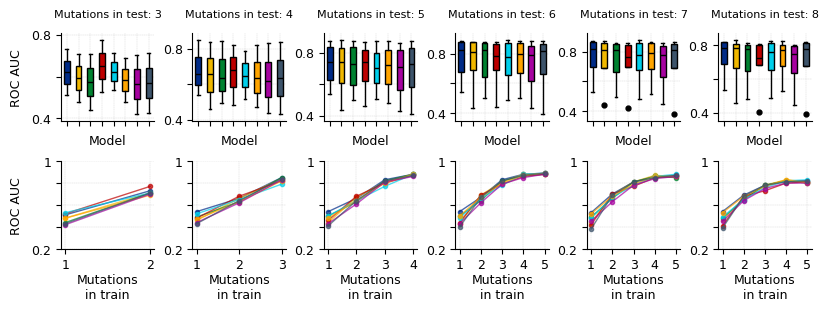

[0.04984967 0.03194039 0.03883599 0.02769926 0.07508182]
[0.04984967 0.03194039 0.03883599 0.02769926 0.07508182]
[0.04984967 0.03194039 0.03883599 0.02769926 0.07508182]
[0.04984967 0.03194039 0.03883599 0.02769926 0.07508182]
[0.04984967 0.03194039 0.03883599 0.02769926 0.07508182]
[0.04984967 0.03194039 0.03883599 0.02769926 0.07508182]


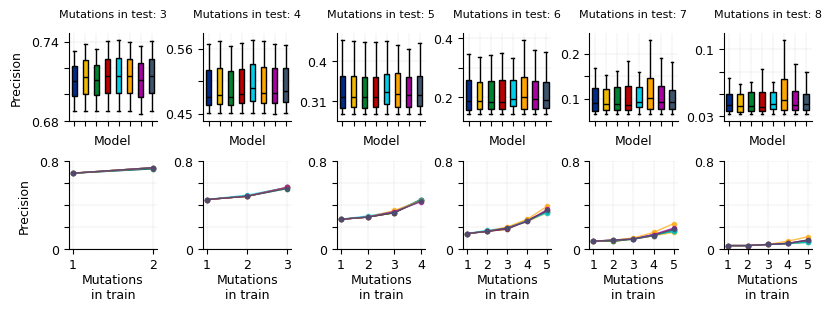

[0.09416797 0.06175167 0.07450536 0.05390537 0.13631994]
[0.09416797 0.06175167 0.07450536 0.05390537 0.13631994]
[0.09416797 0.06175167 0.07450536 0.05390537 0.13631994]
[0.09416797 0.06175167 0.07450536 0.05390537 0.13631994]
[0.09416797 0.06175167 0.07450536 0.05390537 0.13631994]
[0.09416797 0.06175167 0.07450536 0.05390537 0.13631994]


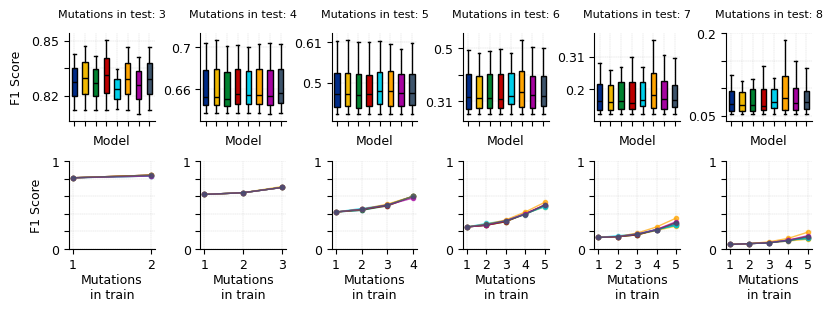

[0.54775782 0.2202531  0.37121053 0.02770776 0.74050445]
[0.54775782 0.2202531  0.37121053 0.02770776 0.74050445]
[0.54775782 0.2202531  0.37121053 0.02770776 0.74050445]
[0.54775782 0.2202531  0.37121053 0.02770776 0.74050445]
[0.54775782 0.2202531  0.37121053 0.02770776 0.74050445]
[0.54775782 0.2202531  0.37121053 0.02770776 0.74050445]


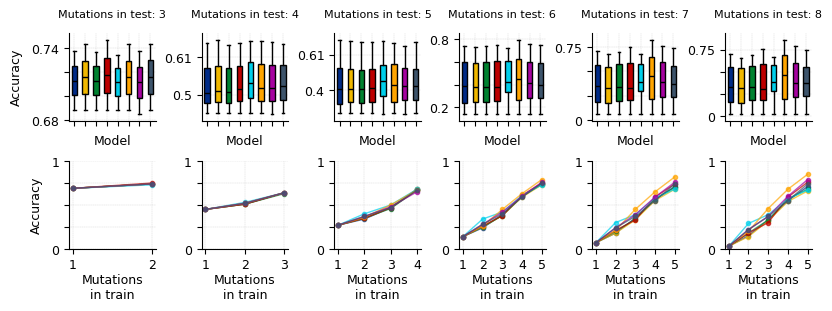

[0.84865719 0.92638231 0.91374408 1.         0.73933649]
[0.84865719 0.92638231 0.91374408 1.         0.73933649]
[0.84865719 0.92638231 0.91374408 1.         0.73933649]
[0.84865719 0.92638231 0.91374408 1.         0.73933649]
[0.84865719 0.92638231 0.91374408 1.         0.73933649]
[0.84865719 0.92638231 0.91374408 1.         0.73933649]


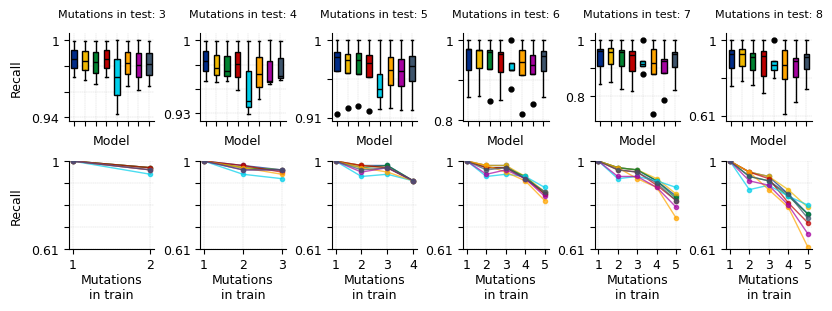

[[0.01785714 0.98214286]
 [0.1209564  0.8790436 ]
 [0.31449237 0.68550763]
 [0.5500246  0.4499754 ]
 [0.73115658 0.26884342]
 [0.8557477  0.1442523 ]
 [0.93330582 0.06669418]
 [0.97230099 0.02769901]
 [0.98810099 0.01189901]
 [0.99216175 0.00783825]]
[[0.01785714 0.98214286]
 [0.1209564  0.8790436 ]
 [0.31449237 0.68550763]
 [0.5500246  0.4499754 ]
 [0.73115658 0.26884342]
 [0.8557477  0.1442523 ]
 [0.93330582 0.06669418]
 [0.97230099 0.02769901]
 [0.98810099 0.01189901]
 [0.99216175 0.00783825]]
[[0.01785714 0.98214286]
 [0.1209564  0.8790436 ]
 [0.31449237 0.68550763]
 [0.5500246  0.4499754 ]
 [0.73115658 0.26884342]
 [0.8557477  0.1442523 ]
 [0.93330582 0.06669418]
 [0.97230099 0.02769901]
 [0.98810099 0.01189901]
 [0.99216175 0.00783825]]
[[0.01785714 0.98214286]
 [0.1209564  0.8790436 ]
 [0.31449237 0.68550763]
 [0.5500246  0.4499754 ]
 [0.73115658 0.26884342]
 [0.8557477  0.1442523 ]
 [0.93330582 0.06669418]
 [0.97230099 0.02769901]
 [0.98810099 0.01189901]
 [0.99216175 0.0078382

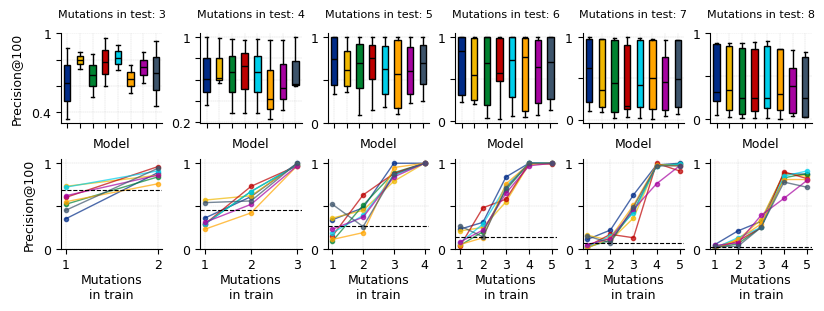


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'model'],
      dtype='object')
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'model'],
      dtype='object')
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'model'],
      dtype='object')
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'mod

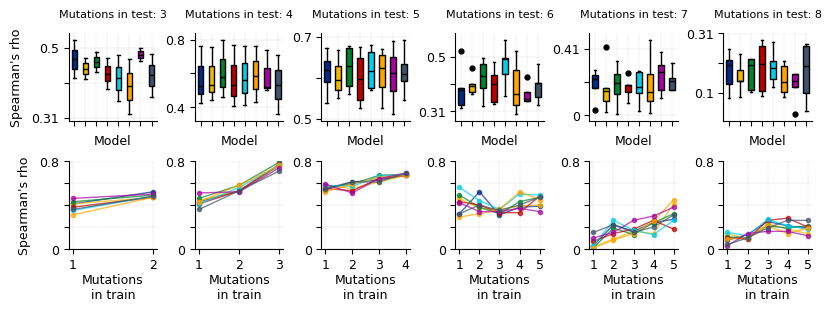


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'model'],
      dtype='object')
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'model'],
      dtype='object')
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'model'],
      dtype='object')
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name'

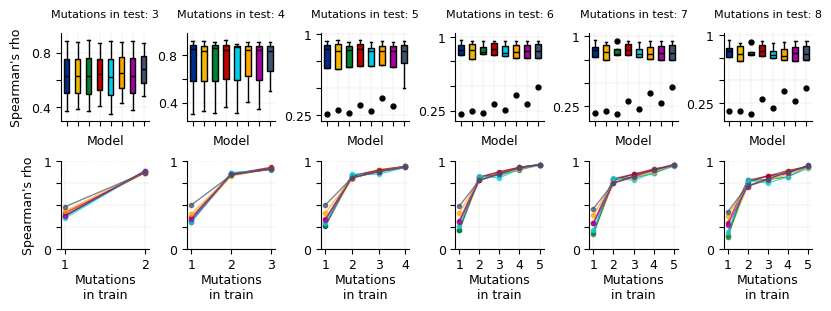

In [17]:




pred_begin = 1
min_muts = 3
n_muts_to_check = 6


for dataset_name in ["gfp", "pard3", "lov"]:
    var_to_use = var_to_use_dict[dataset_name]
    embedding_base_dir = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/%s/%s_regression_optimal" % (dataset_name, dataset_name)
    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)

    for feature_to_plot in var_to_use:
        plot_mutation_model_performance(
            color_map,
            df_all,
            pred_begin,
            min_muts,
            n_muts_to_check,
            feature_to_plot,
            gfp_muts if (dataset_name == "gfp" and feature_to_plot == "top_100_pct") else None,
            output_dir="./refined_figures/figure_models_comparision/%s/" % dataset_name,
            min_max_y=True
        )

In [7]:
#filtered_df_all["model_name"].unique()

filtered_df_all = df_all[df_all["test_mutations"] <= 8]


filtered_df_all["scale"] = np.nan

for model_name in filtered_df_all["model_name"].unique():
    filtered_df_all.loc[filtered_df_all["model_name"] == model_name, "scale"] = discretized_parameter_scale[model_name]


var_explained_factor_results = []

for tm in range(3, 9):
    sub_df = filtered_df_all[(filtered_df_all["test_mutations"] == tm) & (filtered_df_all["train_mutations"] >= 1)]
    ss_all, results_df = calculate_ss_for_df_and_factors(
        sub_df,
        factors=["model_name", "train_mutations", "scale"],
        variables_to_calculate=var_to_use
    )

    for var in var_to_use:#
        for factor in ["model_name", "train_mutations", "scale"]:
            ss_factor_for_var = results_df[(results_df["factor_name"] == factor) & (results_df["var"] == var)]["SS"].sum()
            total_ss_in_var = ss_all[ss_all["var"] == var]["SS"]
            

            var_explained_factor_results.append({"var": var, 
                                                 "factor": factor, 
                                                 "test_mutations": tm, 
                                                 "var_explained": (1 - ss_factor_for_var / total_ss_in_var).item()})

var_explained_factor_df = pd.DataFrame(var_explained_factor_results)

/tmp/ipykernel_2876753/2290975150.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df_all["scale"] = np.nan


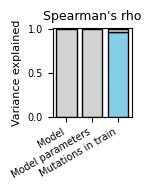

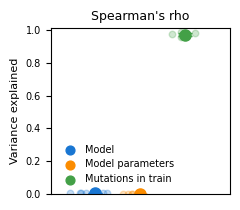

In [8]:

output_dir = "./figures/figure_2"
os.makedirs(output_dir, exist_ok=True)

for var in var_explained_factor_df['var'].unique():
    plot_df = var_explained_factor_df[var_explained_factor_df['var'] == var].copy()
    # Sort/order factors for bar plot
    factor_order = []
    if "model_name" in plot_df['factor'].values:
        factor_order.append("model_name")
    if "scale" in plot_df['factor'].values:
        factor_order.append("scale")
    if "train_mutations" in plot_df['factor'].values:
        factor_order.append("train_mutations")
    factor_order += [f for f in plot_df['factor'].unique() if f not in factor_order]
    # Get mean per factor for bar heights
    means = [plot_df[plot_df['factor'] == f]['var_explained'].mean() for f in factor_order]
    stds = [plot_df[plot_df['factor'] == f]['var_explained'].std() for f in factor_order]
    means = np.array(means)
    stds = np.array(stds)
    leftover = 1.0 - means
    leftover = np.clip(leftover, 0, 1)
    x = np.arange(len(factor_order))
    xlabels = [xlabel_dict.get(f, f) for f in factor_order]

    # --- Bar plot (original) ---
    fig, ax = plt.subplots(figsize=(1.5, 2))
    bar1 = ax.bar(x, means, color="skyblue", edgecolor="k", label='Explained')
    bar2 = ax.bar(x, leftover, bottom=means, color="lightgray", edgecolor="k", label='Unexplained')

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)
    ax.set_ylabel("Variance explained", fontsize=label_fontsize)
    ax.set_title(ylabel_dict[var], fontsize=title_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.set_ylim(0, 1.01)
    #ax.legend(fontsize=legend_fontsize, frameon=False, loc="lower left", bbox_to_anchor=(0,1.01), ncol=2)
    plt.tight_layout()
    #plt.savefig(os.path.join(output_dir, f"var_explained_gfp_{var}_bars.svg"), bbox_inches='tight')
    plt.show()
    plt.close()

    # --- Side-by-side scatter + error bars for factors, colored, no label as x-axis ---
    fig, ax = plt.subplots(figsize=(2.5, 2.2))
    # Choose colors to distinguish factors
    color_palette = ["#1976D2", "#FB8C00", "#43A047", "#8E24AA", "#D32F2F", "#00838F"]
    # Make sure there are enough colors
    factor_colors = {f: color_palette[i % len(color_palette)] for i, f in enumerate(factor_order)}
    # Place all factors at nearly the same x location, but spread a tiny bit to not overlap
    x_center = 0.55
    sep = 0.08  # How much to spread the (n) factors horizontally
    factor_xs = {f: x_center + sep*(i - (len(factor_order)-1)/2) for i, f in enumerate(factor_order)}
    # Scatter: plot values for each factor, at slightly displaced x, color-coded
    for i, f in enumerate(factor_order):
        yvals = plot_df[plot_df['factor'] == f]['var_explained'].values
        if len(yvals) > 0:
            xvals = np.random.normal(loc=factor_xs[f], scale=sep/4, size=len(yvals))
            ax.scatter(xvals, yvals, color=factor_colors[f], alpha=0.25, s=22, zorder=1)
    # Means + errbars
    for i, (f, mean, std) in enumerate(zip(factor_order, means, stds)):
        ax.errorbar(factor_xs[f], mean, yerr=std, fmt='o', 
                    color=factor_colors[f], elinewidth=2, capsize=5, markersize=8, zorder=2)
    # The x-axis is just a dummy, no labels
    ax.set_xlim(x_center - sep*len(factor_order)/1.5, x_center + sep*len(factor_order)/1.5)
    ax.set_xticks([])
    # Custom legend mapping color to factor (using dots)
    for i, f in enumerate(factor_order):
        ax.scatter([], [], color=factor_colors[f], label=xlabel_dict.get(f, f), s=40)
    ax.legend(fontsize=legend_fontsize, frameon=False, loc="best", handletextpad=0.5, borderpad=0.5)
    ax.set_ylabel("Variance explained", fontsize=label_fontsize)
    ax.set_title(ylabel_dict[var], fontsize=title_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.set_ylim(0, 1.01)
    plt.tight_layout()
    plt.show()
    plt.close()

    # # Magnified/delta bar plot: show how much each factor's mean is above the minimum
    # deltas = means - np.min(means)
    # fig, ax = plt.subplots(figsize=(2.2, 2))
    # bar1 = ax.bar(x, deltas, color="orange", edgecolor="k", label='Δ from min')
    # for idx, val in enumerate(deltas):
    #     ax.text(x[idx], val + 0.001, f"{val:.4f}", ha='center', va='bottom', fontsize=6)
    # ax.set_xticks(x)
    # ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=tick_fontsize)
    # ax.set_ylabel("Variance explained (Δ from min)", fontsize=label_fontsize)
    # ax.set_title(ylabel_dict[var] + " (Δ from min)", fontsize=title_fontsize)
    # ax.tick_params(axis='y', labelsize=tick_fontsize)
    # ax.set_ylim(0, max(0.011, np.max(deltas)*1.15))
    # plt.tight_layout()
    # #plt.savefig(os.path.join(output_dir, f"var_explained_gfp_{var}_bars_delta.svg"), bbox_inches='tight')
    # plt.show()
    # plt.close()


In [9]:
best_embedding_df = []

for j in range(1, 6):
    for i in range(j+1, 11):
    
        df = df_all[(df_all["test_mutations"] == i) & (df_all["train_mutations"] == j)]
        max_df = df.max().to_frame().T
        max_df["model_name"] = "llm"
        #max_df = df[df["model_name"] == "esm_35m"]
       # max_df["model_name"] = "llm"
        best_embedding_df.append(max_df)

#best_embedding_df = pd.concat(best_embedding_df)
best_embedding_df = df_all[df_all["model_name"] == "esm_35m"]
best_embedding_df["model_name"] = "llm"


ohe_embedding_df_all = pd.concat([best_embedding_df, ohe_df_all])
#ohe_embedding_df_all


/tmp/ipykernel_2876753/2546260449.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"



Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: progen2-small_flat at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Reading CSV file: progen2-small_evaluation_train_on_4.csv
Reading CSV file: progen2-small_evaluation_train_on_3.csv
Reading CSV file: progen2-sma

/tmp/ipykernel_2876753/1125413961.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


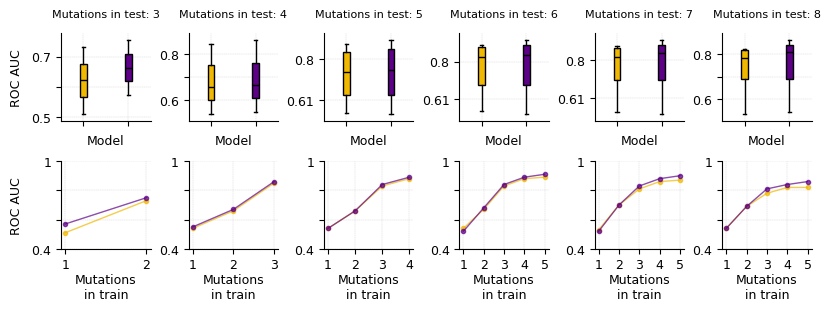

Feature to plot: precision, Max model: progen2-small, gfp


/tmp/ipykernel_2876753/1125413961.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]
[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]
[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]
[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]
[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]
[0.548583   0.76025918 0.76231884 0.02769926 0.03258799]


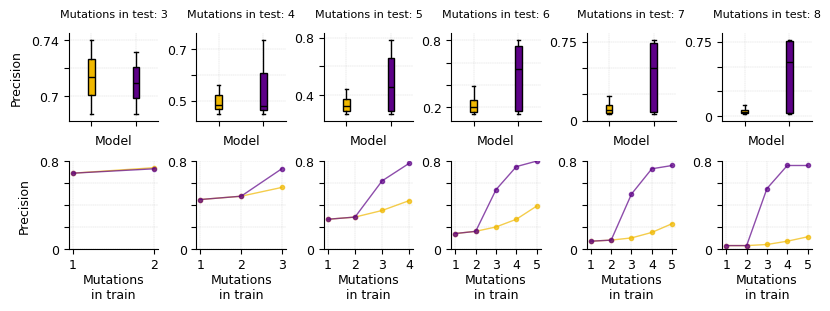

Feature to plot: f1, Max model: progen2-small, gfp
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]
[0.1481279  0.34417013 0.14985755 0.05390537 0.062918  ]


/tmp/ipykernel_2876753/1125413961.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


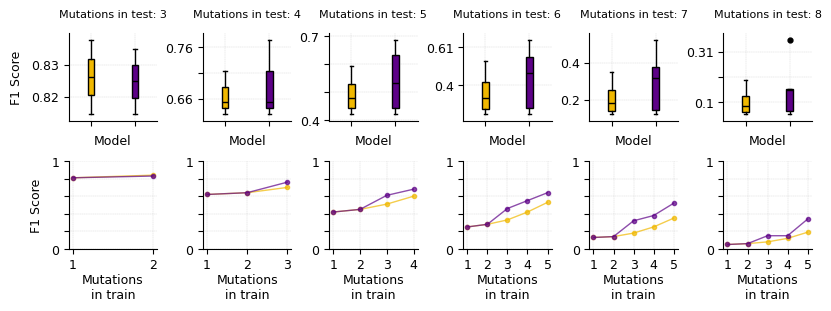

Feature to plot: accuracy, Max model: progen2-small, gfp
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]


/tmp/ipykernel_2876753/1125413961.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]
[0.97272107 0.97651929 0.97388504 0.02770776 0.2507789 ]


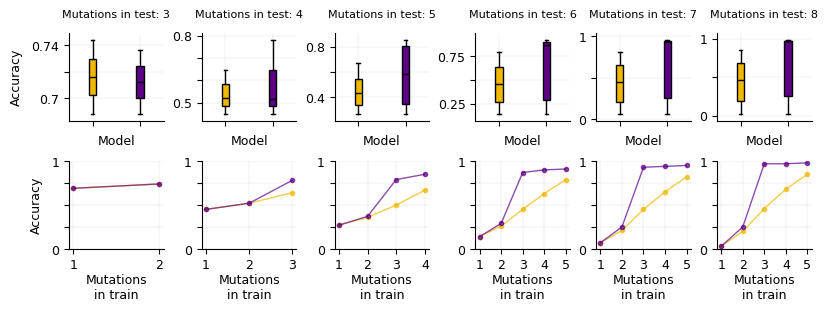

Feature to plot: recall, Max model: esm_8m, gfp
[0.08562401 0.22243286 0.08309637 1.         0.90805687]
[0.08562401 0.22243286 0.08309637 1.         0.90805687]
[0.08562401 0.22243286 0.08309637 1.         0.90805687]
[0.08562401 0.22243286 0.08309637 1.         0.90805687]
[0.08562401 0.22243286 0.08309637 1.         0.90805687]
[0.08562401 0.22243286 0.08309637 1.         0.90805687]


/tmp/ipykernel_2876753/1125413961.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


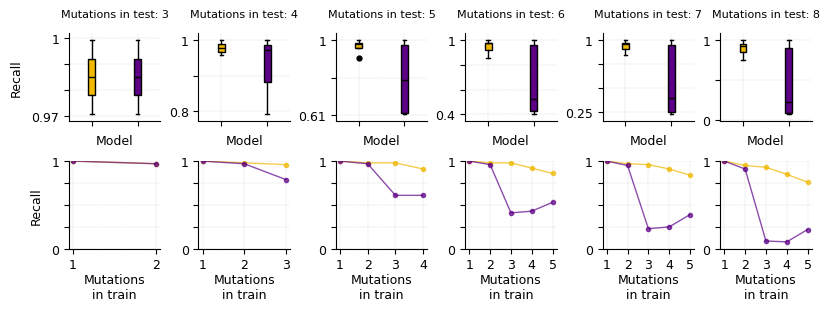

Feature to plot: top_100_pct, Max model: esm_650m, gfp


/tmp/ipykernel_2876753/1125413961.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


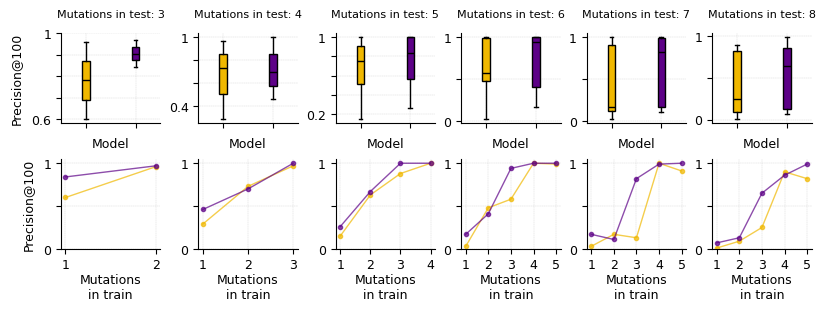


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pard3/pard3_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv


/tmp/ipykernel_2876753/1125413961.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


[0.24439415 0.26134355 0.23887391 0.08827722 0.14394886]
[0.24439415 0.26134355 0.23887391 0.08827722 0.14394886]
[0.24439415 0.26134355 0.23887391 0.08827722 0.14394886]
[0.24439415 0.26134355 0.23887391 0.08827722 0.14394886]
[0.24439415 0.26134355 0.23887391 0.08827722 0.14394886]
[0.24439415 0.26134355 0.23887391 0.08827722 0.14394886]


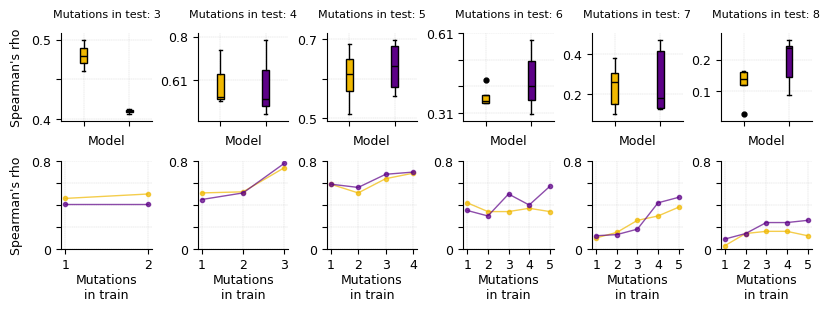


Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: esm_650m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_650m
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_optimal/esm_650m
Reading CSV file: esm_650m_evaluation_train_on_1.csv
Reading CSV file: esm_650m_evaluation_train_on_2.csv
Reading CSV file: esm_650m_evaluation_train_on_5.csv
Reading CSV file

/tmp/ipykernel_2876753/1125413961.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


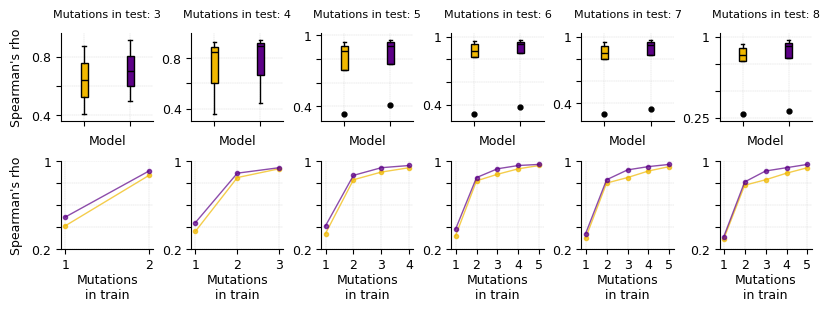

In [12]:
color_map = {
    "llm": "#f0b800",
    "ohe": "#5d0187",
}


pred_begin = 1
min_muts = 3
n_muts_to_check = 6



max_model_df = []
for dataset_name in ["gfp", "pard3", "lov"]:
    var_to_use = var_to_use_dict[dataset_name]
    embedding_base_dir = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/%s/%s_regression_optimal" % (dataset_name, dataset_name)
    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)

    var_to_use = var_to_use_dict[dataset_name]

    for feature_to_plot in var_to_use:

        mean_correlations = df_all.groupby("model_name")[feature_to_plot].median()
        max_model = mean_correlations.idxmax()
        print("Feature to plot: %s, Max model: %s, %s" % (feature_to_plot, max_model, dataset_name))

        max_model_df.append({
            "model_name": max_model,
            "feature": feature_to_plot,
            "dataset": dataset_name
        })
        
        best_embedding_df = df_all[df_all["model_name"] == max_model]
        best_embedding_df["model_name"] = "llm"
        ohe_embedding_df_all = pd.concat([best_embedding_df, ohe_df_all])

        ohe_embedding_df_all[feature_to_plot] = ohe_embedding_df_all[feature_to_plot].astype(np.float64)
        
        plot_mutation_model_performance(
            color_map,
            ohe_embedding_df_all,
            pred_begin,
            min_muts,
            n_muts_to_check,
            feature_to_plot,
            min_max_y=True,
            output_dir="./refined_figures/figure_ohe_vs_llm/%s/" % dataset_name,
            #probabilities_by_mutations,
            #output_dir="./figures/figure_3_regular/"
        )

In [16]:
base_path = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data"
ratio_df = []
epsilon = 10 ** -8
datasets_feature_to_use_dict = {"gfp": ["roc", "precision", "f1", "accuracy", "recall", "top_100_pct"],
"lov": ["correlation"],
"pard3": ["correlation"]
 }

for k, v in datasets_feature_to_use_dict.items():

    embedding_base_dir = os.path.join(base_path, k, f"{k}_regression_optimal")

    df_all, ohe_df_all = load_df_all(embedding_base_dir, one_hot=True)

    for feature_to_plot in v:

        mean_correlations = df_all.groupby("model_name")[feature_to_plot].median()
        max_model = mean_correlations.idxmax()
        best_embedding_df = df_all[df_all["model_name"] == max_model]
        best_embedding_df["model_name"] = "llm"
        ohe_embedding_df_all = pd.concat([best_embedding_df, ohe_df_all])

        for train_mutation in ohe_embedding_df_all["train_mutations"].unique():
            for test_mutation in ohe_embedding_df_all["test_mutations"].unique():        
                sub_df = ohe_embedding_df_all[(ohe_embedding_df_all["train_mutations"] == train_mutation) & (ohe_embedding_df_all["test_mutations"] == test_mutation)]
                
                if len(sub_df) == 0:
                    continue

                ohe_value = sub_df[sub_df["model_name"] == "ohe"][feature_to_plot].item()
                llm_value = sub_df[sub_df["model_name"] == "llm"][feature_to_plot].item()

                if llm_value == 0:
                    continue

                print(ohe_value, llm_value)
                
                ratio_df.append({
                    "train_mutations": train_mutation, 
                    "test_mutations": test_mutation, 
                    "ratio": (ohe_value) / (llm_value ), 
                    "ohe_value": ohe_value, 
                    "llm_value": llm_value,
                    "feature": feature_to_plot,
                    "dataset": k
                })



Processing model directory: esm_3b at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/esm_3b
Reading CSV file: esm_3b_evaluation_train_on_1.csv
Reading CSV file: esm_3b_evaluation_train_on_4.csv
Reading CSV file: esm_3b_evaluation_train_on_3.csv
Reading CSV file: esm_3b_evaluation_train_on_5.csv
Reading CSV file: esm_3b_evaluation_train_on_2.csv

Processing model directory: progen2-small_flat at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Found 5 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/gfp/gfp_regression_optimal/progen2-small_flat
Reading CSV file: progen2-small_evaluation_train_on_4.csv
Reading CSV file: progen2-small_evaluation_train_on_3.csv
Reading CSV file: progen2-sma

/tmp/ipykernel_3795265/4041093752.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"
/tmp/ipykernel_3795265/4041093752.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"
/tmp/ipykernel_3795265/4041093752.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

0.3175447075882068 0.1824649948302752
0.1481279037988521 0.0823185800943608
0.0040513166779203 0.0332863684395914
nan 0.0200482172313158
0.7631394533987387 0.7034407427635172
0.4239030505641454 0.4239030505641454
0.2521586105948719 0.2521586105948719
0.1250525012710834 0.1250525012710834
0.0539053718022958 0.0539053718022958
0.0235185538794475 0.0235185538794475
0.0155545821774468 0.0155545821774468
0.6209745882619276 0.6209745882619276
0.937640871525169 0.937640871525169
0.8147204078381391 0.8147204078381391
0.6354142127993717 0.5294714587737844
0.5203214160940958 0.3498701081035782
0.3441701295526766 0.1867568873852102
0.0832266325224071 0.0689695550351288
nan 0.0323078171929539
0.450810149801284 0.4484348459111866
0.2796392975794969 0.2765254315517401
0.144911459531121 0.1408371113365783
0.0629180029992228 0.0612117809198101
0.0255816862646985 0.0256972188821224
0.0160067504506692 0.0161838329751599
0.644122965641953 0.6433082341510808
0.8347329526368827 0.837516960651289
0.84907593

/tmp/ipykernel_3795265/4041093752.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"
/tmp/ipykernel_3795265/4041093752.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_embedding_df["model_name"] = "llm"


In [14]:
rdf = pd.DataFrame(ratio_df)

In [15]:
nmt_base_path = "%s/nmt/results/by_complexity_and_budget_up_to_11/" % base_path
gcn_base_path = "%s/gcn4/results/by_complexity_and_budget_up_to_8/" % base_path




nmt_sets = load_df_with_budget(nmt_base_path)
nmt_train = [5,6,7,8,9]
nmt_test = [9, 10, 11]

gcn_sets = load_df_with_budget(gcn_base_path)
gcn_train = [3,4,5,6]
gcn_test = [6, 7, 8]

In [18]:



all_datasets = [("nmt", nmt_sets, 0.85),
                ("gcn", gcn_sets, 0.5)]


by_subsamples_df = []
for dataset_name, sets, percentile in all_datasets:

    all_ohe_df_list = []
    all_not_ohe_df_list = []

    for set_name, df in sets.items():
        ohe_df = df[df["model_name"] == "one_hot"]
        not_ohe_df = df[df["model_name"] != "one_hot"]
        all_ohe_df_list.append(ohe_df)
        all_not_ohe_df_list.append(not_ohe_df)
    



    all_ohe_df = pd.concat(all_ohe_df_list)
    all_not_ohe_df = pd.concat(all_not_ohe_df_list)
    best_model = all_not_ohe_df.groupby("model_name")["cor_llm"].mean().idxmax()

    max_model_df.append({
        "model_name": best_model,
        "feature": "spearman_rho",
        "dataset": dataset_name
    })
    best_model_df = all_not_ohe_df[all_not_ohe_df["model_name"] == best_model]


    all_ohe_df["cor_llm"] = all_ohe_df["cor_llm"].abs()
    best_model_df["cor_llm"] = best_model_df["cor_llm"].abs()

    ohe_grouped = all_ohe_df.groupby(['set_name', 'max_muts_in_train', 'budget'], as_index=False).quantile(percentile)
    best_model_grouped = best_model_df.groupby(['set_name', 'max_muts_in_train', 'budget'], as_index=False).quantile(percentile)


    llm_value = best_model_grouped["cor_llm"].to_numpy()
    working_indices = llm_value != 0

    ohe_grouped = ohe_grouped[working_indices]
    best_model_grouped = best_model_grouped[working_indices]

    ohe_value = ohe_grouped["cor_llm"].to_numpy()
    llm_value = best_model_grouped["cor_llm"].to_numpy()



    by_subsamples_df.append(pd.DataFrame({
                        "train_mutations": ohe_grouped["max_muts_in_train"].to_numpy(), 
                        "test_mutations": np.array([int(x.split("_")[-1]) for x in ohe_grouped["set_name"].to_list()]), 
                        "ratio": (ohe_value) / (llm_value), 
                        "ohe_value": ohe_value, 
                        "llm_value": llm_value,
                        "feature": np.array(["|Spearman's Rho|"] * len(ohe_value)),
                        "dataset": np.array([dataset_name] * len(ohe_value))
                    }))



/tmp/ipykernel_2876753/3288365508.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_model_df["cor_llm"] = best_model_df["cor_llm"].abs()
/tmp/ipykernel_2876753/3288365508.py:35: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ohe_grouped = all_ohe_df.groupby(['set_name', 'max_muts_in_train', 'budget'], as_index=False).quantile(percentile)
/tmp/ipykernel_2876753/3288365508.py:36: FutureWarning: The default value of numeric_only in DataFrameGroupBy.quantile is deprecated. In a future version, numeric_only will default to False. Either specify numeri

In [19]:
ratio_df_all = pd.DataFrame(ratio_df)
ratio_df_all = ratio_df_all[ratio_df_all["test_mutations"] <= 8]
ratio_df_all = pd.concat([ratio_df_all] + by_subsamples_df)


In [20]:
ratio_df_all

,train_mutations,test_mutations,ratio,ohe_value,llm_value,feature,dataset
0,3,4,1.016401,0.861049,0.847154,roc,gfp
1,3,5,1.014531,0.837711,0.825713,roc,gfp
2,3,6,1.013316,0.837047,0.826048,roc,gfp
3,3,7,1.023158,0.833630,0.814761,roc,gfp
4,3,8,1.034784,0.809465,0.782255,roc,gfp
...,...,...,...,...,...,...,...
67,7,8,0.605263,0.123214,0.203571,|Spearman's Rho|,gcn
68,7,8,0.693431,0.169643,0.244643,|Spearman's Rho|,gcn
69,7,8,0.947826,0.194643,0.205357,|Spearman's Rho|,gcn
70,7,8,1.718750,0.196429,0.114286,|Spearman's Rho|,gcn


In [21]:
ratio_df_all.loc[ratio_df_all["dataset"] == "gfp", "dataset"] = "GFP"
ratio_df_all.loc[ratio_df_all["dataset"] == "pard3", "dataset"] = "PARD3"
ratio_df_all.loc[ratio_df_all["dataset"] == "nmt", "dataset"] = "NMT"
ratio_df_all.loc[ratio_df_all["dataset"] == "gcn", "dataset"] = "GCN4"
ratio_df_all.loc[ratio_df_all["dataset"] == "lov", "dataset"] = "LOV"
ratio_df_all["title_for_plot"] = [ylabel_dict[k] if k in ylabel_dict.keys() else k for k in ratio_df_all["feature"].to_list()]


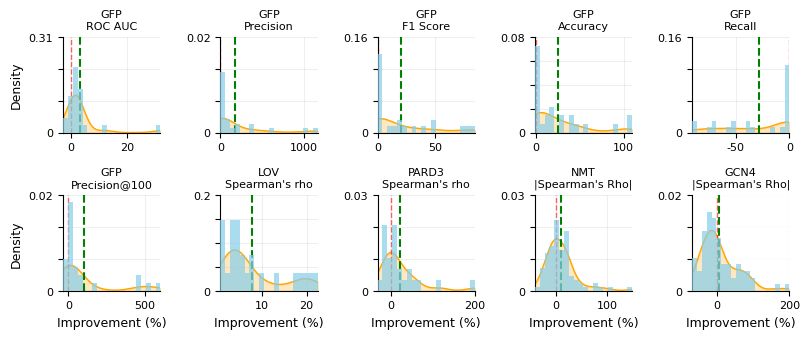

In [22]:

# Iterate over all possible datasets and features in the data for plotting

datasets = ratio_df_all["dataset"].unique()
features = ratio_df_all["feature"].unique()

plot_pairs = []
for dataset in datasets:
    for feature in features:
        subgrp = ratio_df_all[(ratio_df_all["dataset"] == dataset) & (ratio_df_all["feature"] == feature)]
        if len(subgrp) > 0:
            fancy_title = ratio_df_all[(ratio_df_all["dataset"] == dataset) & (ratio_df_all["feature"] == feature)]["title_for_plot"].unique()[0]
            plot_pairs.append((dataset, feature, subgrp, fancy_title))

nplots = len(plot_pairs)
ncols = 5
nrows = int(np.ceil(nplots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.2, 3.5))
axes = axes.flatten()

for i, (dataset, feature, group, fancy_title) in enumerate(plot_pairs):
    ax = axes[i]
    statistic = (group["ratio"] - 1) * 100

    # Plot histogram
    counts, bins, patches = ax.hist(
        statistic, bins=20, color='skyblue', alpha=0.7, density=True, label='Histogram',
        zorder=3
    )

    # Plot KDE
    if len(statistic) > 1:
        xmin, xmax = bins[0], bins[-1]
        x = np.linspace(xmin, xmax, 500)
        kde = stats.gaussian_kde(statistic, bw_method=0.4)
        y = kde(x)
        ax.plot(x, y, color='orange', linewidth=1, label='Density (KDE)', zorder=2)
        ax.fill_between(x, y, color='orange', alpha=0.25, zorder=2)
    else:
        xmin, xmax = ax.get_xlim()

    # Add mean line
    mean_val = np.mean(statistic)
    ax.axvline(mean_val, color='green', linestyle='--', label=f'Mean = {mean_val:.2f}')
    # Reference line at Zero Improvement
    ax.axvline(0, color="red", linestyle="--", lw=1, alpha=0.6, label="No Improvement")

    ax.set_title(f"{dataset}\n{fancy_title}", fontsize=8)
    if i == 0 or i == 5:
        ax.set_ylabel("Density", fontsize=9)
    else:
        ax.set_ylabel("")
    if i >= ncols:
        ax.set_xlabel("Improvement (%)", fontsize=9)
    else:
        ax.set_xlabel("")

    ax.set_xlim(xmin, xmax)

    fix_ticks(ax, 
              y=True,
              x=False,
              every_other=False,
              fontsize=8)
    
    fix_ticks(ax, 
              y=False,
              x=True,
              every_other=False,
              xlim=[xmin,xmax],
              fontsize=8)

    plt.grid(True, which='major', linestyle='--', linewidth=0.25, alpha=0.7)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(alpha=0.2)

# Turn off extra axes (if any)
for j in range(len(plot_pairs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("./refined_figures/figure_ohe_vs_llm/improvement_plot.svg", bbox_inches='tight')
plt.show()

In [23]:
def load_df_all_new(embedding_base_dir, one_hot=False):

    df_all_list = []

    experiment_dirs = [d for d in os.listdir(embedding_base_dir) if os.path.isdir(os.path.join(embedding_base_dir, d))]
    llms_experiment_dirs = [e for e in experiment_dirs if e != "one_hot"]

    for exp_subdir in llms_experiment_dirs:
        exp_path = os.path.join(embedding_base_dir, exp_subdir)
        csv_files = [f for f in os.listdir(exp_path) if f.endswith('.csv')]
        print(f"\nProcessing model directory: {exp_subdir} at {exp_path}")
        print(f"Found {len(csv_files)} csv files in {exp_path}")

        for csv_file in csv_files:
            csv_path = os.path.join(exp_path, csv_file)
            print(f"Reading CSV file: {csv_file}")
            df = pd.read_csv(csv_path)
            df["model"] = exp_subdir
            df_all_list.append(df)
            print(df.columns)

    if len(df_all_list) > 0:
        df_all = pd.concat(df_all_list, ignore_index=True)
        print(f"\nConcatenating {len(df_all_list)} dataframes into df_all...")
        print(f"df_all shape: {df_all.shape}")
    else:
        df_all = pd.DataFrame()


    if one_hot:
        ohe_experiment_dirs = [e for e in experiment_dirs if e == "one_hot"][0]
        ohe_df_all_list = []
        ohe_dir = os.path.join(embedding_base_dir, ohe_experiment_dirs)
        csv_files = [f for f in os.listdir(ohe_dir) if f.endswith('.csv')]
        for csv_file in csv_files:
            df = pd.read_csv(os.path.join(ohe_dir, csv_file))
            ohe_df_all_list.append(df)
        if len(ohe_df_all_list) > 0:
            ohe_df_all = pd.concat(ohe_df_all_list, ignore_index=True)
        else:
            ohe_df_all = pd.DataFrame()

        ohe_df_all["model_name"] = "ohe"

        return (df_all, ohe_df_all)

    return df_all

a = load_df_all_new("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_model_comp/", one_hot=False)
a["model_name"] = a["clf_type"]

new_color_map = {
    "xgboost": "#f0b800",
    "ridgeregression": "#5d0187",
    "mlp": "red",
}


Processing model directory: esm_8m at /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_model_comp/esm_8m
Found 15 csv files in /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/lov/lov_regression_model_comp/esm_8m
Reading CSV file: esm_8m_evaluation_train_on_5_xgboost.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_1_ridgeregression.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_4_mlp.csv
Index(['correlation', 'p_value', 'test_mutations', 'train_mutations',
       'classifier', 'model_name', 'clf_type', 'model'],
      dtype='object')
Reading CSV file: esm_8m_evaluation_train_on_1_xgboost.csv
Index(['correlation', 'p

In [22]:
a

,correlation,p_value,test_mutations,train_mutations,classifier,model_name,clf_type,model
0,0.946333,0.0,6,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,xgboost,esm_8m
1,0.930733,0.0,7,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,xgboost,esm_8m
2,0.913077,0.0,8,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,xgboost,esm_8m
3,0.895804,0.0,9,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,xgboost,esm_8m
4,0.876569,0.0,10,5,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,xgboost,esm_8m
...,...,...,...,...,...,...,...,...
100,0.811033,0.0,6,2,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,mlp,esm_8m
101,0.783048,0.0,7,2,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,mlp,esm_8m
102,0.757000,0.0,8,2,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,mlp,esm_8m
103,0.738395,0.0,9,2,/home/labs/fleishman/itayta/new_fitness_repo/f...,esm_8m,mlp,esm_8m


[0.85806001 0.82581847 0.9452663  0.15590341 0.75699999]
[0.85806001 0.82581847 0.9452663  0.15590341 0.75699999]
[0.85806001 0.82581847 0.9452663  0.15590341 0.75699999]
[0.85806001 0.82581847 0.9452663  0.15590341 0.75699999]
[0.85806001 0.82581847 0.9452663  0.15590341 0.75699999]
[0.85806001 0.82581847 0.9452663  0.15590341 0.75699999]


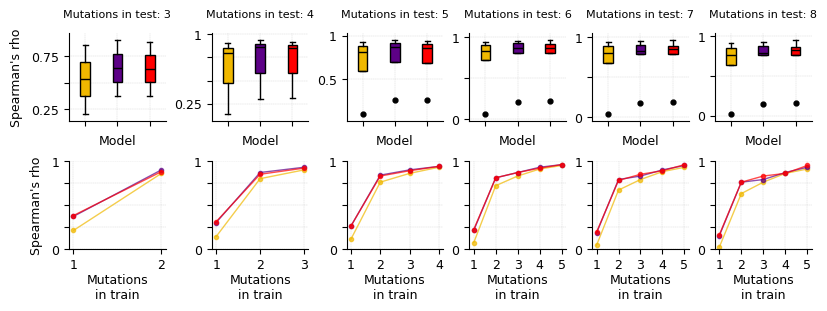

In [24]:
plot_mutation_model_performance(
            new_color_map,
            a,
            pred_begin,
            min_muts,
            n_muts_to_check,
            var_to_use_dict["lov"][0],
            min_max_y=True,
            output_dir=None
            #output_dir="./refined_figures/figure_ohe_vs_llm/%s/" % dataset_name,
            #probabilities_by_mutations,
            #output_dir="./figures/figure_3_regular/"
        )

In [22]:
color_map

{'xgboost': '#f0b800', 'ridgeregression': '#5d0187', 'mlp': '#008000'}